In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Food_Delivery_Times_CSV.csv")

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
# df['Weather']=df['Weather'].fillna(df['Weather'].mode())

In [7]:
# df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode())

In [8]:
df['Time_of_Day']=df['Time_of_Day'].fillna(df['Time_of_Day'].mode())

In [9]:
df['Courier_Experiece_yrs']=df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
 9   Courier_Experiece_yrs   1000 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [11]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
Courier_Experiece_yrs      0
dtype: int64

In [14]:
df.dropna(inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 883 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                883 non-null    int64  
 1   Distance_km             883 non-null    float64
 2   Weather                 883 non-null    object 
 3   Traffic_Level           883 non-null    object 
 4   Time_of_Day             883 non-null    object 
 5   Vehicle_Type            883 non-null    object 
 6   Preparation_Time_min    883 non-null    int64  
 7   Courier_Experience_yrs  883 non-null    float64
 8   Delivery_Time_min       883 non-null    int64  
 9   Courier_Experiece_yrs   883 non-null    float64
dtypes: float64(3), int64(3), object(4)
memory usage: 75.9+ KB


In [18]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Courier_Experiece_yrs
count,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000
mean,508.109853,10.051586,17.019253,4.639864,56.425821,4.639864
std,287.925161,5.688582,7.260201,2.922172,21.568482,2.922172
min,1.000000,0.590000,5.000000,0.000000,8.000000,0.000000
25%,263.500000,5.130000,11.000000,2.000000,41.000000,2.000000
50%,512.000000,10.280000,17.000000,5.000000,55.000000,5.000000
75%,758.500000,15.025000,23.000000,7.000000,71.000000,7.000000
max,1000.000000,19.990000,29.000000,9.000000,141.000000,9.000000


In [19]:
df.groupby('Traffic_Level')['Delivery_Time_min'].mean()

Traffic_Level
High      64.298343
Low       52.498559
Medium    56.250704
Name: Delivery_Time_min, dtype: float64

In [20]:
df.groupby('Weather')['Delivery_Time_min'].mean()

Weather
Clear    52.668235
Foggy    59.663265
Rainy    59.095745
Snowy    66.813953
Windy    55.081395
Name: Delivery_Time_min, dtype: float64

In [21]:
df.groupby('Time_of_Day')['Delivery_Time_min'].mean()

Time_of_Day
Afternoon    56.108949
Evening      57.509294
Morning      56.405694
Night        53.736842
Name: Delivery_Time_min, dtype: float64

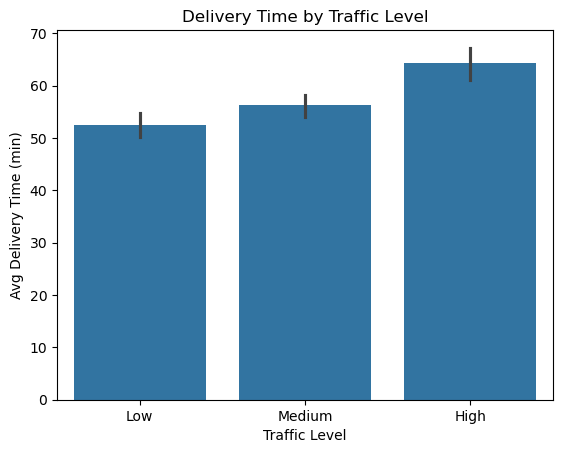

In [23]:
plt.figure()
sns.barplot(x='Traffic_Level', y='Delivery_Time_min', data=df)
plt.title("Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Avg Delivery Time (min)")
plt.show()

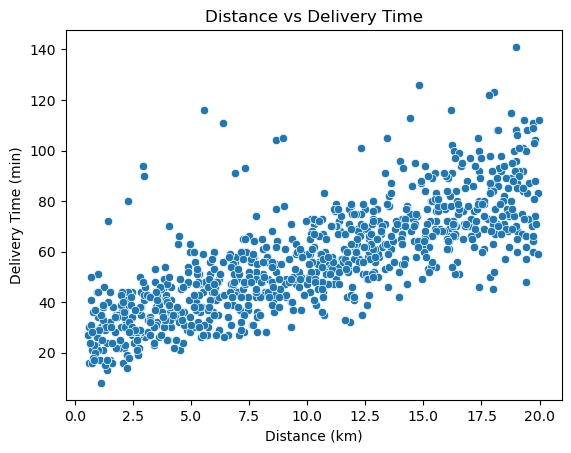

In [24]:
plt.figure()
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()

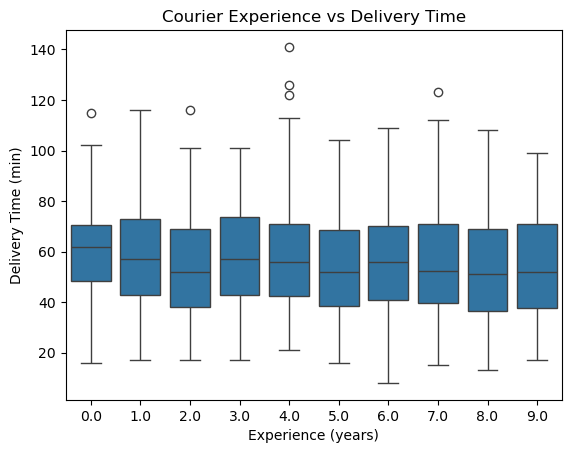

In [25]:
plt.figure()
sns.boxplot(x='Courier_Experience_yrs', y='Delivery_Time_min', data=df)
plt.title("Courier Experience vs Delivery Time")
plt.xlabel("Experience (years)")
plt.ylabel("Delivery Time (min)")
plt.show()

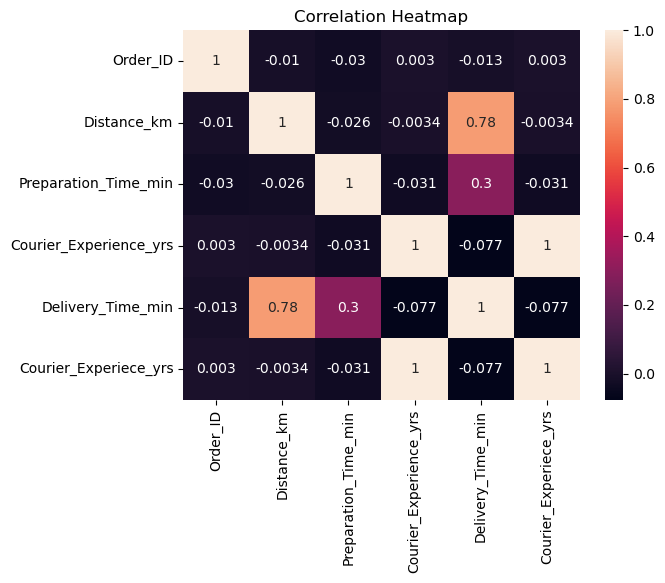

In [26]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()